<a href="https://colab.research.google.com/github/likhith-kumarn/Data_Science/blob/main/Diamond_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

data = np.array([10,12,14,15,18,20,22,100])

# Calculate Q1 and Q3
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
print(Q1)
print(Q3)
# Calculate IQR
IQR = Q3 - Q1

# Calculate limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Limit:", lower_bound)
print("Upper Limit:", upper_bound)

# Detect outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]

print("Outliers:", outliers)

13.5
20.5
Lower Limit: 3.0
Upper Limit: 31.0
Outliers: [100]


In [3]:
import pandas as pd
url='https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv'
df=pd.read_csv(url)
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [5]:
df.head()
df.tail()

,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [8]:
df.shape


(53940, 10)

In [9]:
print(df.columns)

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')


In [13]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [12]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


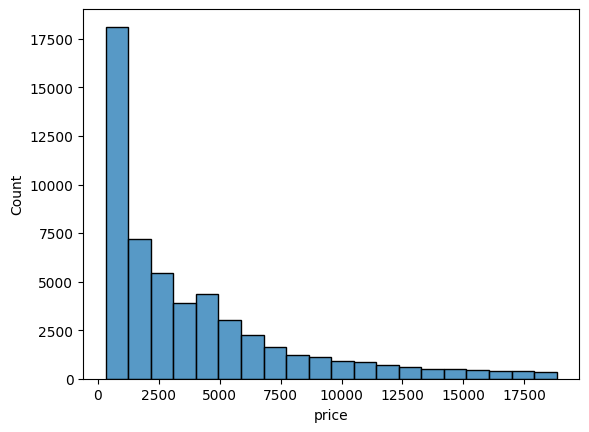

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['price'],bins=20)
plt.show()

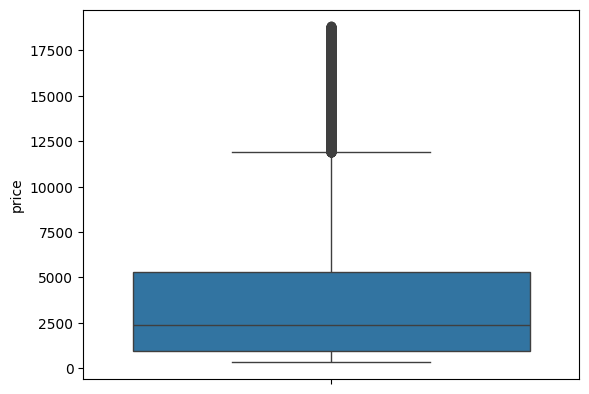

In [22]:
sns.boxplot(df['price'])
plt.show()

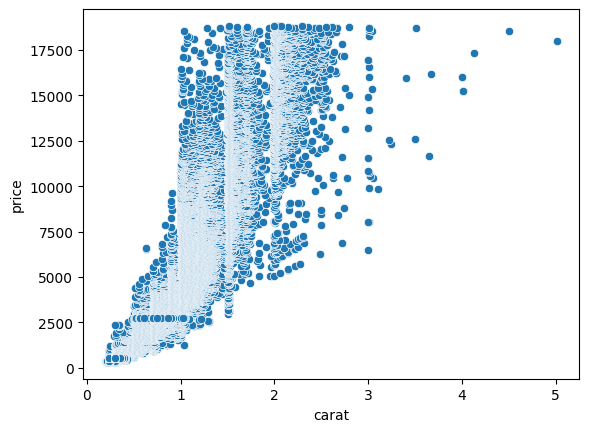

In [23]:
sns.scatterplot(x="carat", y="price", data=df)
plt.show()

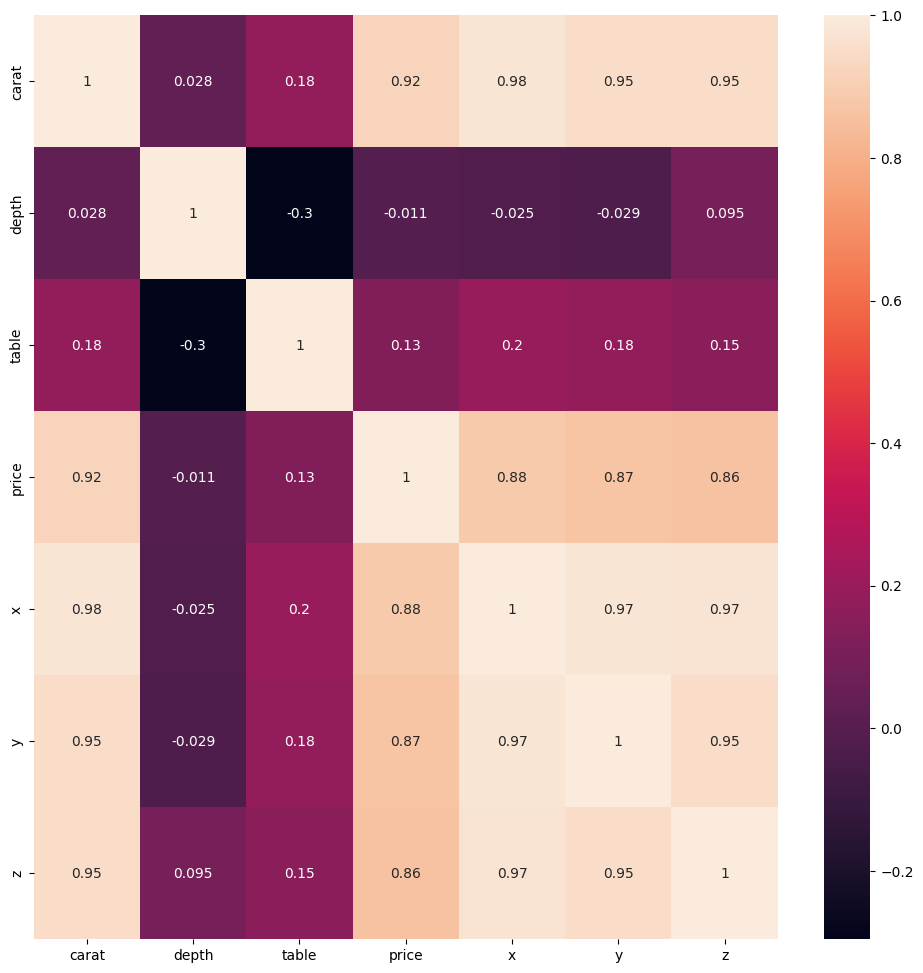

In [29]:
plt.figure(figsize=(12,12))
cor=df.corr(numeric_only=True)
sns.heatmap(cor,annot=True)
plt.show()

In [33]:
x = df.drop('price', axis=1)
x.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75


In [31]:
y=df['price']
y.head()

,price
0,326
1,326
2,327
3,334
4,335


In [35]:
x=pd.get_dummies(x,drop_first=True)
x.head()

,carat,depth,table,x,y,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,3.95,3.98,2.43,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,3.89,3.84,2.31,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,4.05,4.07,2.31,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,4.20,4.23,2.63,False,False,False,True,...,True,False,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,4.34,4.35,2.75,False,True,False,False,...,False,True,False,False,False,True,False,False,False,False


In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [37]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [38]:
y_pred=model.predict(x_test)

In [39]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(mse)
print(score)

1288705.4778516742
0.9189331350419387


In [40]:
from sklearn.ensemble import RandomForestRegressor
randomforest=RandomForestRegressor()
randomforest.fit(x_train,y_train)

RandomForestRegressor()

In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=5)

grid.fit(x_train, y_train)

print(grid.best_params_)

{'max_depth': 20, 'n_estimators': 200}


In [46]:
from sklearn.model_selection import cross_val_score
cross_score=cross_val_score(randomforest,x,y,cv=5)
print(cross_score)

[ 0.49420727  0.501905    0.68086684 -0.35093427  0.173985  ]


In [47]:
cross_score.mean()

np.float64(0.30000596827921966)

In [50]:
cor=df.corr(numeric_only=True)
high_corr=cor[cor>0.9]
high_corr

,carat,depth,table,price,x,y,z
carat,1.000000,NaN,NaN,0.921591,0.975094,0.951722,0.953387
depth,NaN,1.0,NaN,NaN,NaN,NaN,NaN
table,NaN,NaN,1.0,NaN,NaN,NaN,NaN
price,0.921591,NaN,NaN,1.000000,NaN,NaN,NaN
x,0.975094,NaN,NaN,NaN,1.000000,0.974701,0.970772
y,0.951722,NaN,NaN,NaN,0.974701,1.000000,0.952006
z,0.953387,NaN,NaN,NaN,0.970772,0.952006,1.000000


In [52]:
price_per_carat=df['price']/df['carat']
price_per_carat

,0
0,1417.391304
1,1552.380952
2,1421.739130
3,1151.724138
4,1080.645161
...,...
53935,3829.166667
53936,3829.166667
53937,3938.571429
53938,3205.813953


In [53]:
from sklearn.ensemble import GradientBoostingRegressor
gradient=GradientBoostingRegressor()
gradient.fit(x_train,y_train)

GradientBoostingRegressor()

In [54]:
y_pred_gradient = gradient.predict(x_test)
mse_gradient = mean_squared_error(y_test, y_pred_gradient)
score_gradient = r2_score(y_test, y_pred_gradient)
print("Gradient Boosting Regressor MSE:", mse_gradient)
print("Gradient Boosting Regressor R2 Score:", score_gradient)

Gradient Boosting Regressor MSE: 517483.05426442646
Gradient Boosting Regressor R2 Score: 0.9674473884071069


In [55]:
import numpy as np
df['price']=np.log(df['price'])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,5.786897,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,5.786897,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,5.789960,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,5.811141,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,5.814131,4.34,4.35,2.75


In [56]:
best_random_forest_model = RandomForestRegressor(**grid.best_params_)
best_random_forest_model.fit(x_train, y_train)
y_pred_rf = best_random_forest_model.predict(x_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
score_rf = r2_score(y_test, y_pred_rf)

print("Tuned Random Forest Regressor MSE:", mse_rf)
print("Tuned Random Forest Regressor R2 Score:", score_rf)

Tuned Random Forest Regressor MSE: 302265.8373342919
Tuned Random Forest Regressor R2 Score: 0.9809857688682575


In [57]:
import pandas as pd

performance_data = {
    'Model': ['Linear Regression', 'Tuned Random Forest', 'Gradient Boosting Regressor'],
    'MSE': [mse, mse_rf, mse_gradient],
    'R2 Score': [score, score_rf, score_gradient]
}

performance_df= pd.DataFrame(performance_data)
print("\nModel Performance Comparison:")
display(performance_df)


Model Performance Comparison:


,Model,MSE,R2 Score
0,Linear Regression,1.288705e+06,0.918933
1,Tuned Random Forest,3.022658e+05,0.980986
2,Gradient Boosting Regressor,5.174831e+05,0.967447


In [58]:
import numpy as np

# Revert df['price'] to its original scale
df['price'] = np.exp(df['price'])

# Display the head to confirm the change
display(df.head())

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75


In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# Define a parameter grid for GradientBoostingRegressor
param_grid_gradient = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize GridSearchCV
grid_gradient = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gradient, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_gradient.fit(x_train, y_train)

# Print the best parameters found
print("Best parameters for Gradient Boosting Regressor:", grid_gradient.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Gradient Boosting Regressor: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
